In [2]:
import pandas as pd
from IPython.display import display

test_df = pd.read_csv("BigMartSales Prediction/Test.csv")
train_df = pd.read_csv("BigMartSales Prediction/Train.csv")

print(train_df.shape, test_df.shape)
print(train_df.index)
print(train_df.columns)

(8523, 12) (5681, 11)
RangeIndex(start=0, stop=8523, step=1)
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')


In [3]:
import numpy as np

display(train_df.head(5))

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
print(np.unique(train_df["Item_Fat_Content"]))

['LF' 'Low Fat' 'Regular' 'low fat' 'reg']


In [5]:
print(np.unique(train_df["Item_Type"]))

['Baking Goods' 'Breads' 'Breakfast' 'Canned' 'Dairy' 'Frozen Foods'
 'Fruits and Vegetables' 'Hard Drinks' 'Health and Hygiene' 'Household'
 'Meat' 'Others' 'Seafood' 'Snack Foods' 'Soft Drinks' 'Starchy Foods']


In [6]:
print(train_df["Outlet_Size"].unique())

['Medium' nan 'High' 'Small']


In [7]:
print(np.unique(train_df["Outlet_Location_Type"]))

['Tier 1' 'Tier 2' 'Tier 3']


In [8]:
print(np.unique(train_df["Outlet_Type"]))

['Grocery Store' 'Supermarket Type1' 'Supermarket Type2'
 'Supermarket Type3']


In [9]:
stats = train_df["Item_Fat_Content"].value_counts()
StatsDF = pd.DataFrame({'Item_Fat_Content':stats.index, 'Frequency':stats.values})
display(StatsDF)

,Item_Fat_Content,Frequency
0,Low Fat,5089
1,Regular,2889
2,LF,316
3,reg,117
4,low fat,112


In [10]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [11]:
train_df.describe(include='object')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [13]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [14]:
train_df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [15]:
test_df.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [16]:
train_df.Item_Weight = train_df.Item_Weight.fillna(train_df.Item_Weight.mean())
train_df.Outlet_Size = train_df.Outlet_Size.fillna(train_df.Outlet_Size.mode().iloc[0])
test_df.Item_Weight = test_df.Item_Weight.fillna(test_df.Item_Weight.mean())
test_df.Outlet_Size = test_df.Outlet_Size.fillna(test_df.Outlet_Size.mode().iloc[0])

In [17]:
train_df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [18]:
test_df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [19]:
train_df.Item_Fat_Content.value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [20]:
test_df.Item_Fat_Content.value_counts()

Item_Fat_Content
Low Fat    3396
Regular    1935
LF          206
reg          78
low fat      66
Name: count, dtype: int64

In [21]:
train_df.Item_Fat_Content = train_df.Item_Fat_Content.str.replace('low fat', 'Low Fat')
train_df.Item_Fat_Content = train_df.Item_Fat_Content.str.replace('LF', 'Low Fat')
train_df.Item_Fat_Content = train_df.Item_Fat_Content.str.replace('reg', 'Regular')

test_df.Item_Fat_Content = test_df.Item_Fat_Content.str.replace('low fat', 'Low Fat')
test_df.Item_Fat_Content = test_df.Item_Fat_Content.str.replace('LF', 'Low Fat')
test_df.Item_Fat_Content = test_df.Item_Fat_Content.str.replace('reg', 'Regular')

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64


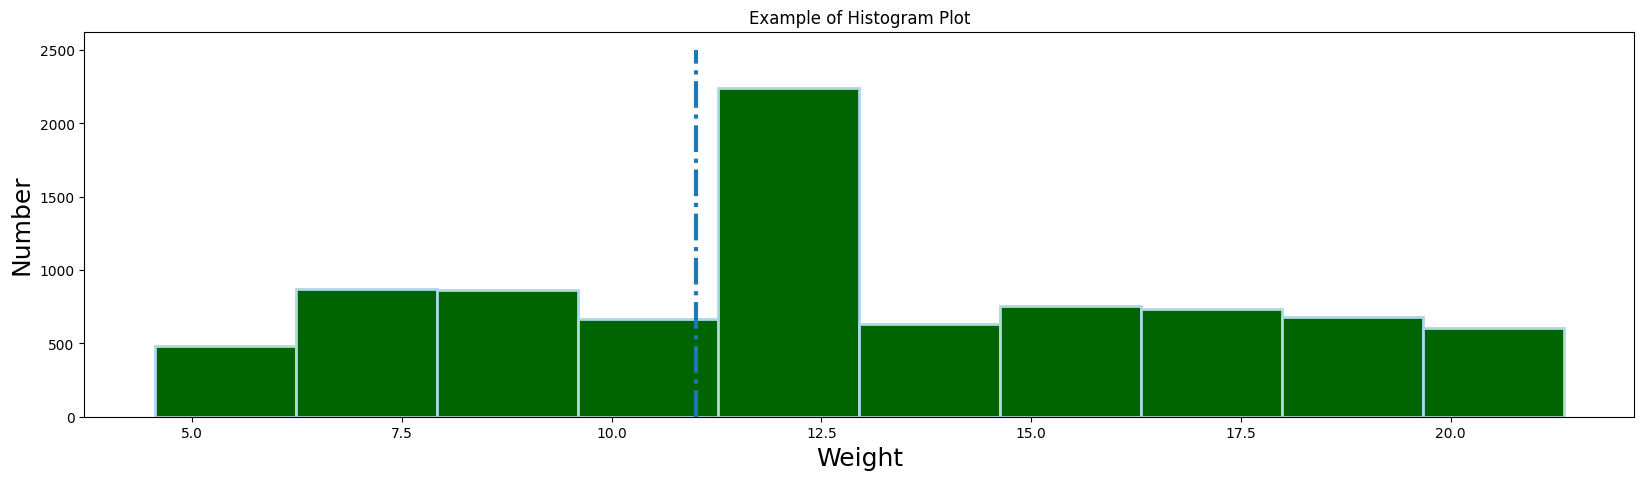

In [22]:
import matplotlib.pyplot as plt

# Plot the distribution of numpy data

print(train_df.Item_Weight)
train_df.Item_Weight.plot(
    kind="hist", edgecolor="lightblue", lw=2, color="darkgreen", figsize=(20, 5)
)
plt.plot([11, 11], [0, 2500], ls="-.", lw=3)
# Add axis labels
plt.xlabel("Weight", fontsize=18)
plt.ylabel("Number", fontsize=18)
plt.title("Example of Histogram Plot")
plt.show()

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


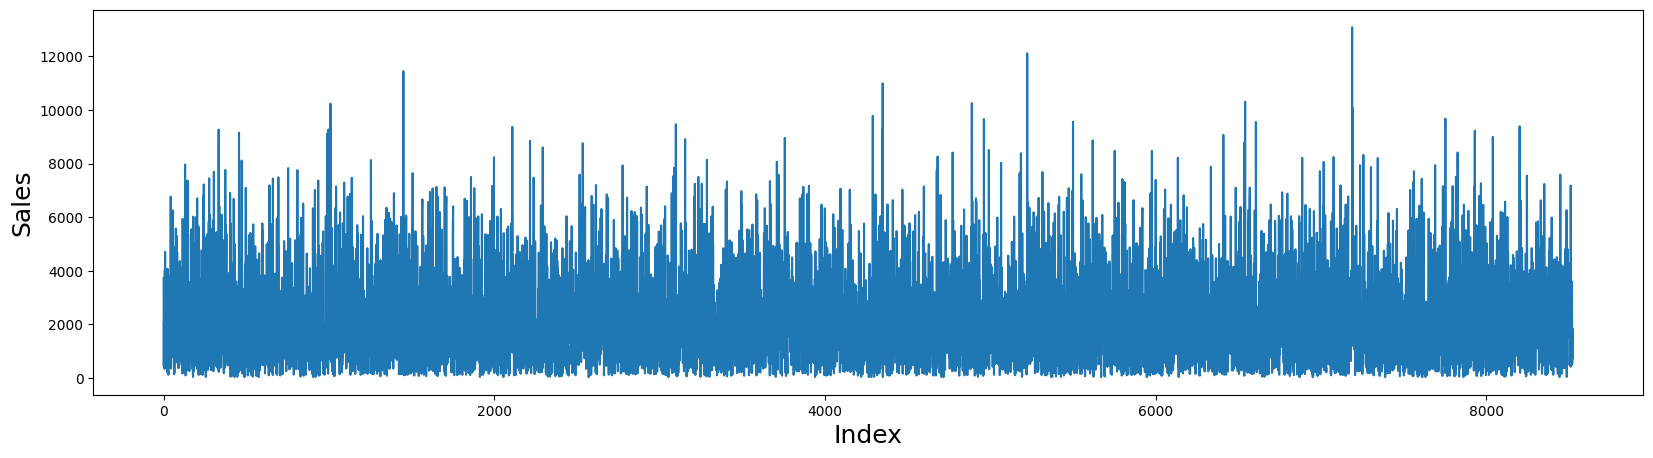

In [23]:
import seaborn as sns

plt.figure(figsize=(20, 5))
print(train_df["Item_Outlet_Sales"])
plt.plot(train_df.index, train_df["Item_Outlet_Sales"])

plt.xlabel("Index", fontsize=18)
plt.ylabel("Sales", fontsize=18)
plt.show()

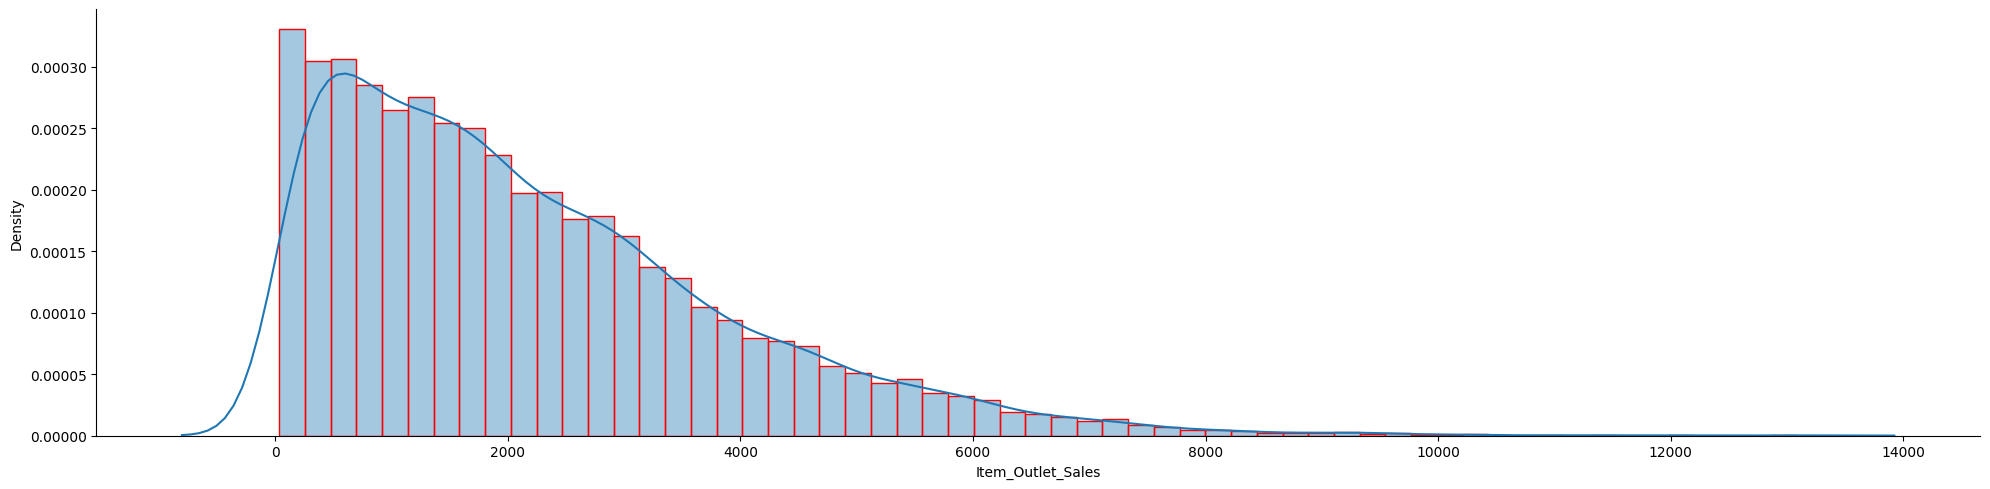

In [24]:
sns.displot(
    train_df["Item_Outlet_Sales"],
    kde=True,
    stat="density",
    kde_kws=dict(cut=3),
    alpha=0.4,
    edgecolor="red",
    height=5,
    aspect=4,
)

<Axes: xlabel='Item_Type', ylabel='count'>

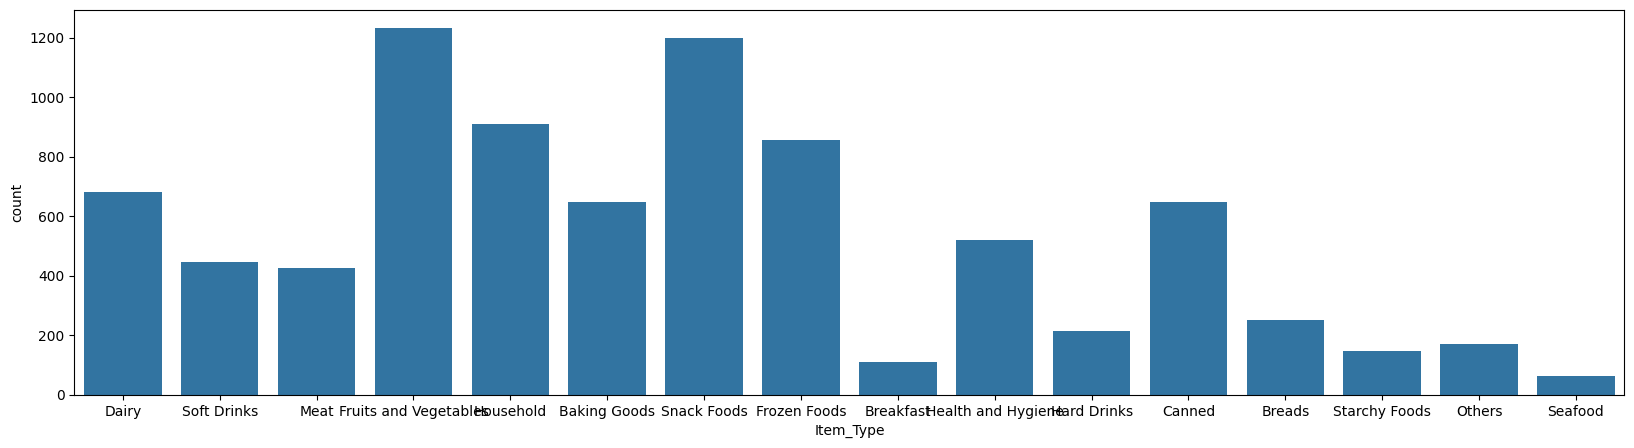

In [25]:
import seaborn as sns

plt.figure(figsize=(20, 5))
sns.countplot(x="Item_Type", data=train_df)

<Axes: xlabel='count', ylabel='Item_Fat_Content'>

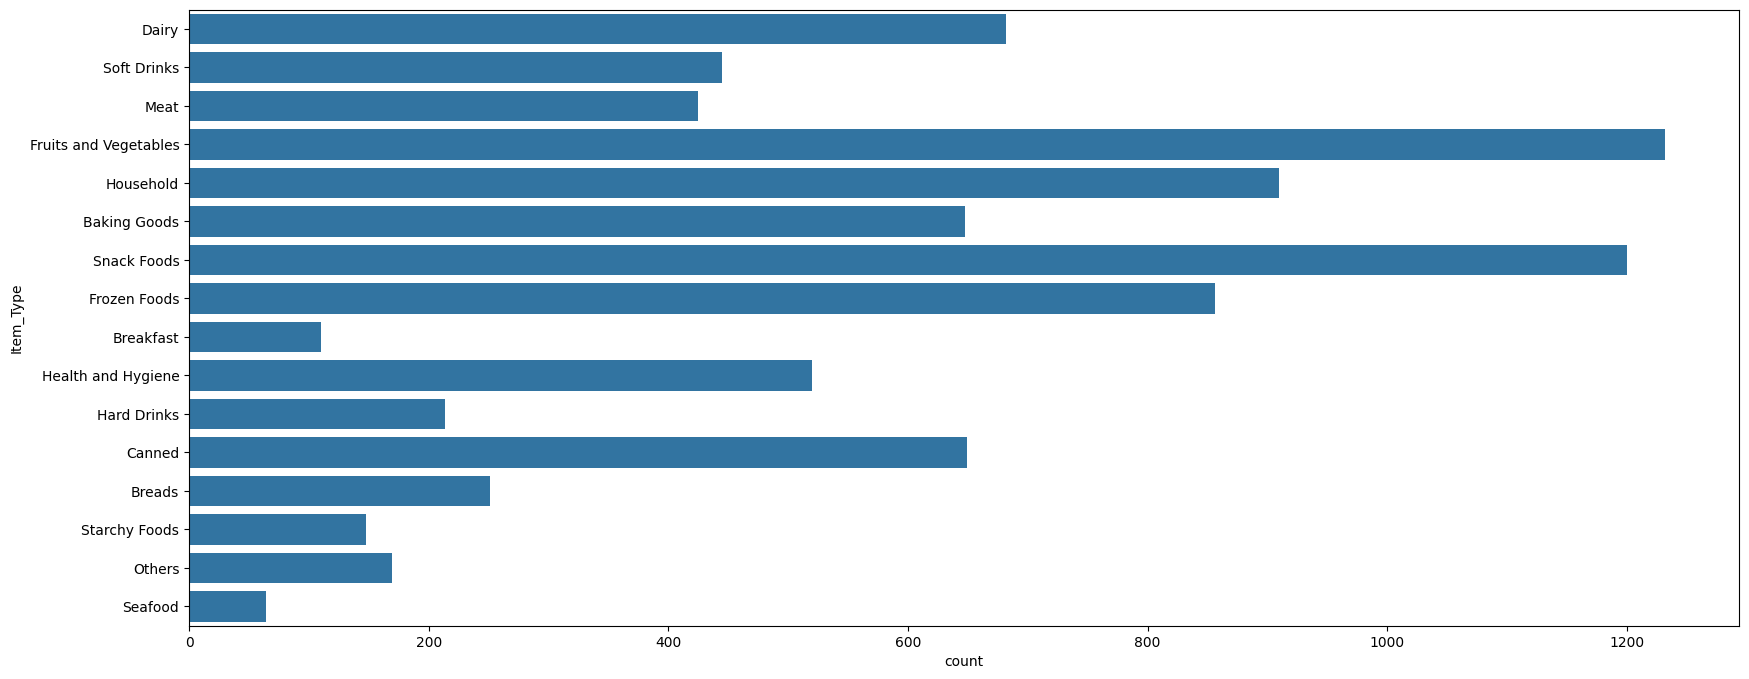

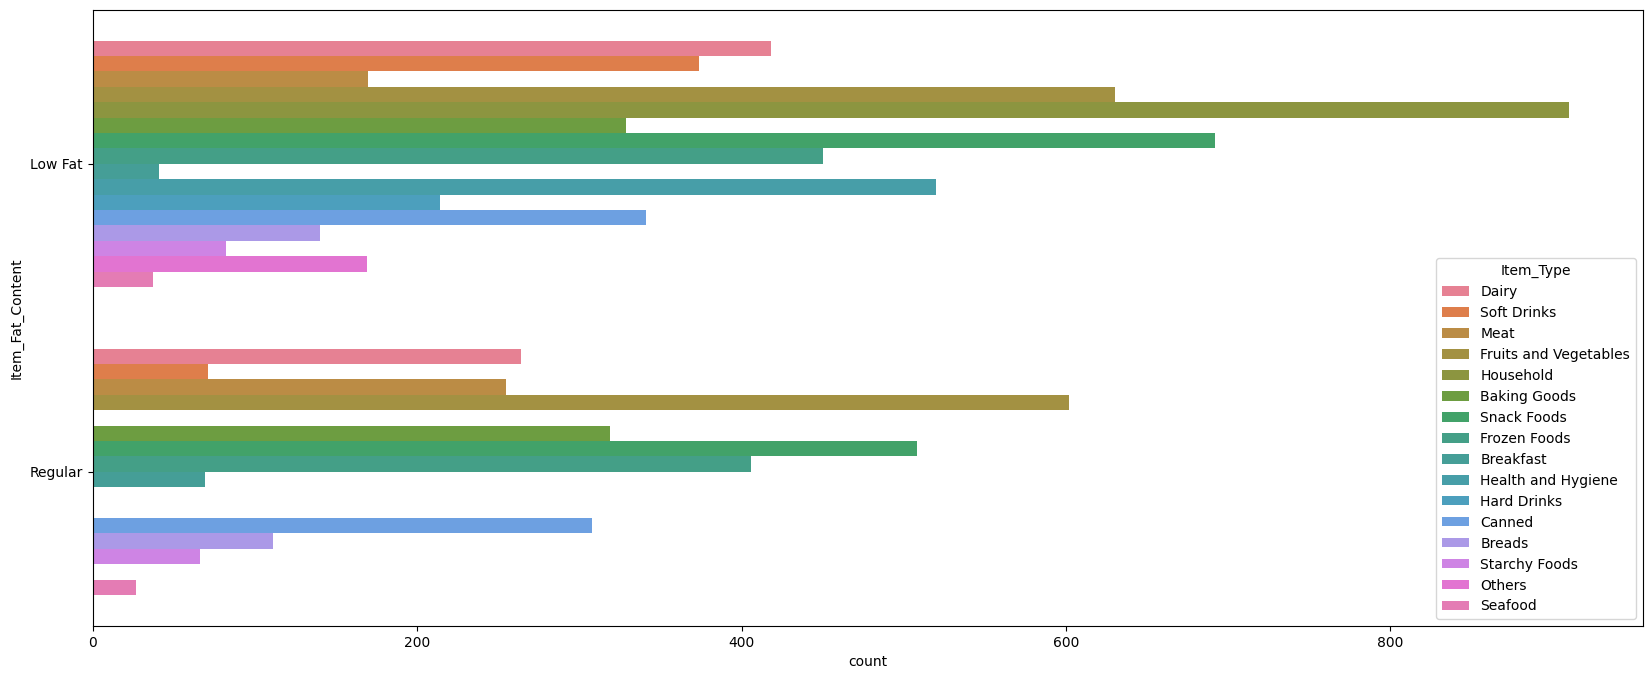

In [26]:
import seaborn as sns

plt.figure(figsize=(20, 8))
sns.countplot(y="Item_Type", data=train_df)

plt.figure(figsize=(20, 8))
sns.countplot(y="Item_Fat_Content", hue="Item_Type", data=train_df)

<Axes: >

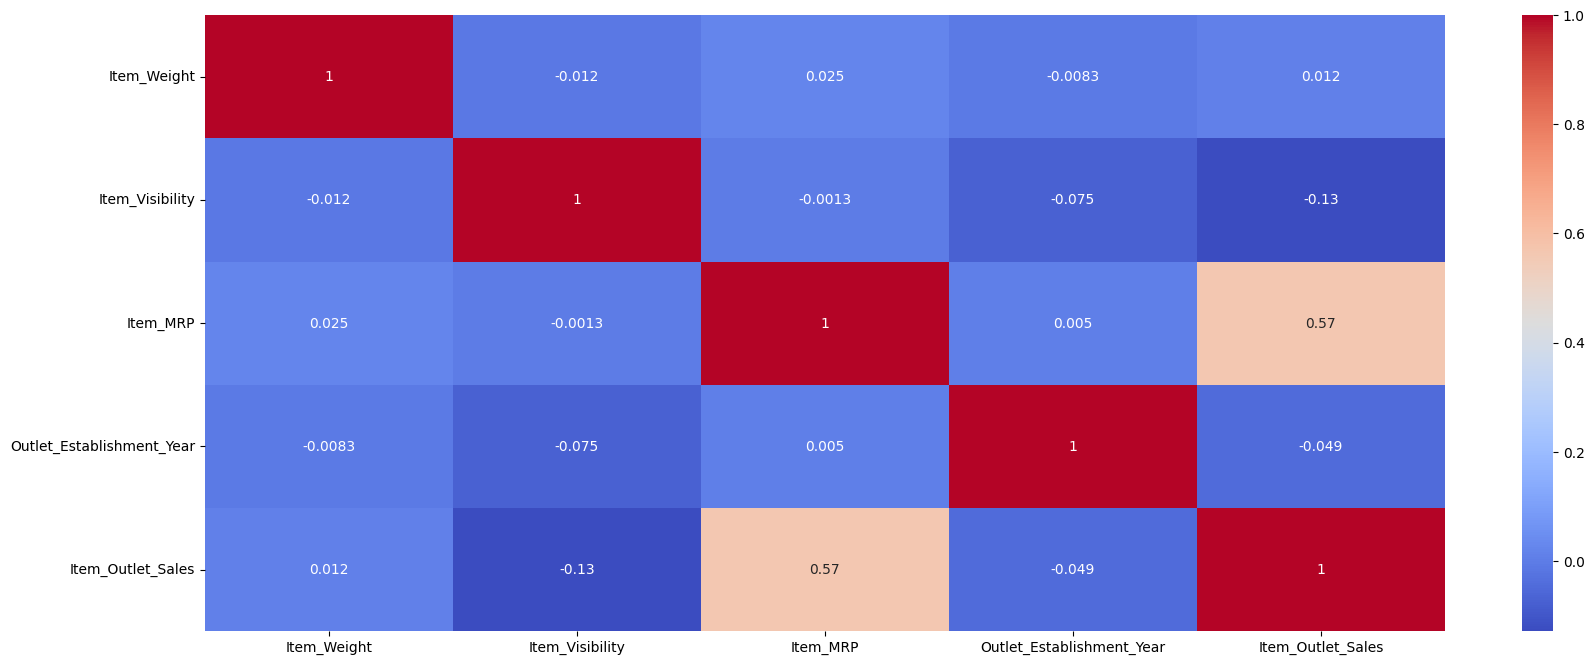

In [27]:
train = train_df.select_dtypes(include=[float, int])
plt.figure(figsize=(20, 8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm", cbar=True)

In [28]:
x_train = train_df[["Item_Weight", "Item_Visibility", "Item_MRP"]]
x_test = test_df[["Item_Weight", "Item_Visibility", "Item_MRP"]]
y_train = train_df["Item_Outlet_Sales"]
#y_test = test_df["Item_Outlet_Sales"]

In [29]:
display(x_train.head())
x_train.shape

,Item_Weight,Item_Visibility,Item_MRP
0,9.30,0.016047,249.8092
1,5.92,0.019278,48.2692
2,17.50,0.016760,141.6180
3,19.20,0.000000,182.0950
4,8.93,0.000000,53.8614


(8523, 3)

In [30]:
display(y_train[:5])
#y_train.shape

0    3735.1380
1     443.4228
2    2097.2700
3     732.3800
4     994.7052
Name: Item_Outlet_Sales, dtype: float64

In [31]:
from sklearn.neighbors import KNeighborsRegressor

neigh = KNeighborsRegressor(n_neighbors=5)
neigh.fit(x_train, y_train)

KNeighborsRegressor()

In [32]:
y_train_pred = neigh.predict(x_train)
PredictDF = train_df.copy()
PredictDF["Item_Outlet_Sales_Predict"] = y_train_pred

# Answer

In [33]:
display(PredictDF)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Outlet_Sales_Predict
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,4138.87912
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,755.54984
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,1512.96392
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,2895.43104
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,813.74076
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,3467.48640
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850,2042.80756
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,1425.34464
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,1866.10424


## Mean Squared Error

In [35]:
from sklearn.metrics import mean_squared_error
print("Mean Squared Error:", mean_squared_error(y_train, y_train_pred))

Mean Squared Error: 1592930.9239806563


## Finding the Best Value for n_neighbors

In [36]:
from sklearn.model_selection import cross_val_score

mse_scores=[]
k_values = range(1, 100)
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    # Use cross-validation to evaluate the model
    scores = cross_val_score(knn, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mse_scores.append(-np.mean(scores))

print(mse_scores)

[np.float64(3980435.566384518), np.float64(2950238.4388083173), np.float64(2654300.529449762), np.float64(2465541.9919493897), np.float64(2363781.7377050114), np.float64(2279420.1942947316), np.float64(2236294.4217127203), np.float64(2198404.8851990737), np.float64(2172495.507902208), np.float64(2155392.118316028), np.float64(2135461.8003250123), np.float64(2123708.876733832), np.float64(2113690.5803408334), np.float64(2103228.2837535525), np.float64(2097961.1248769662), np.float64(2091263.331527857), np.float64(2089490.6554720544), np.float64(2086466.7440292512), np.float64(2080099.7616206459), np.float64(2073184.2333059434), np.float64(2073251.798254934), np.float64(2066739.1615038174), np.float64(2060660.6102193203), np.float64(2060313.4163570434), np.float64(2054655.3226562892), np.float64(2049679.6763232413), np.float64(2048592.1622343692), np.float64(2044020.6443627528), np.float64(2038435.1568033858), np.float64(2036086.1581773981), np.float64(2032810.328895383), np.float64(2026

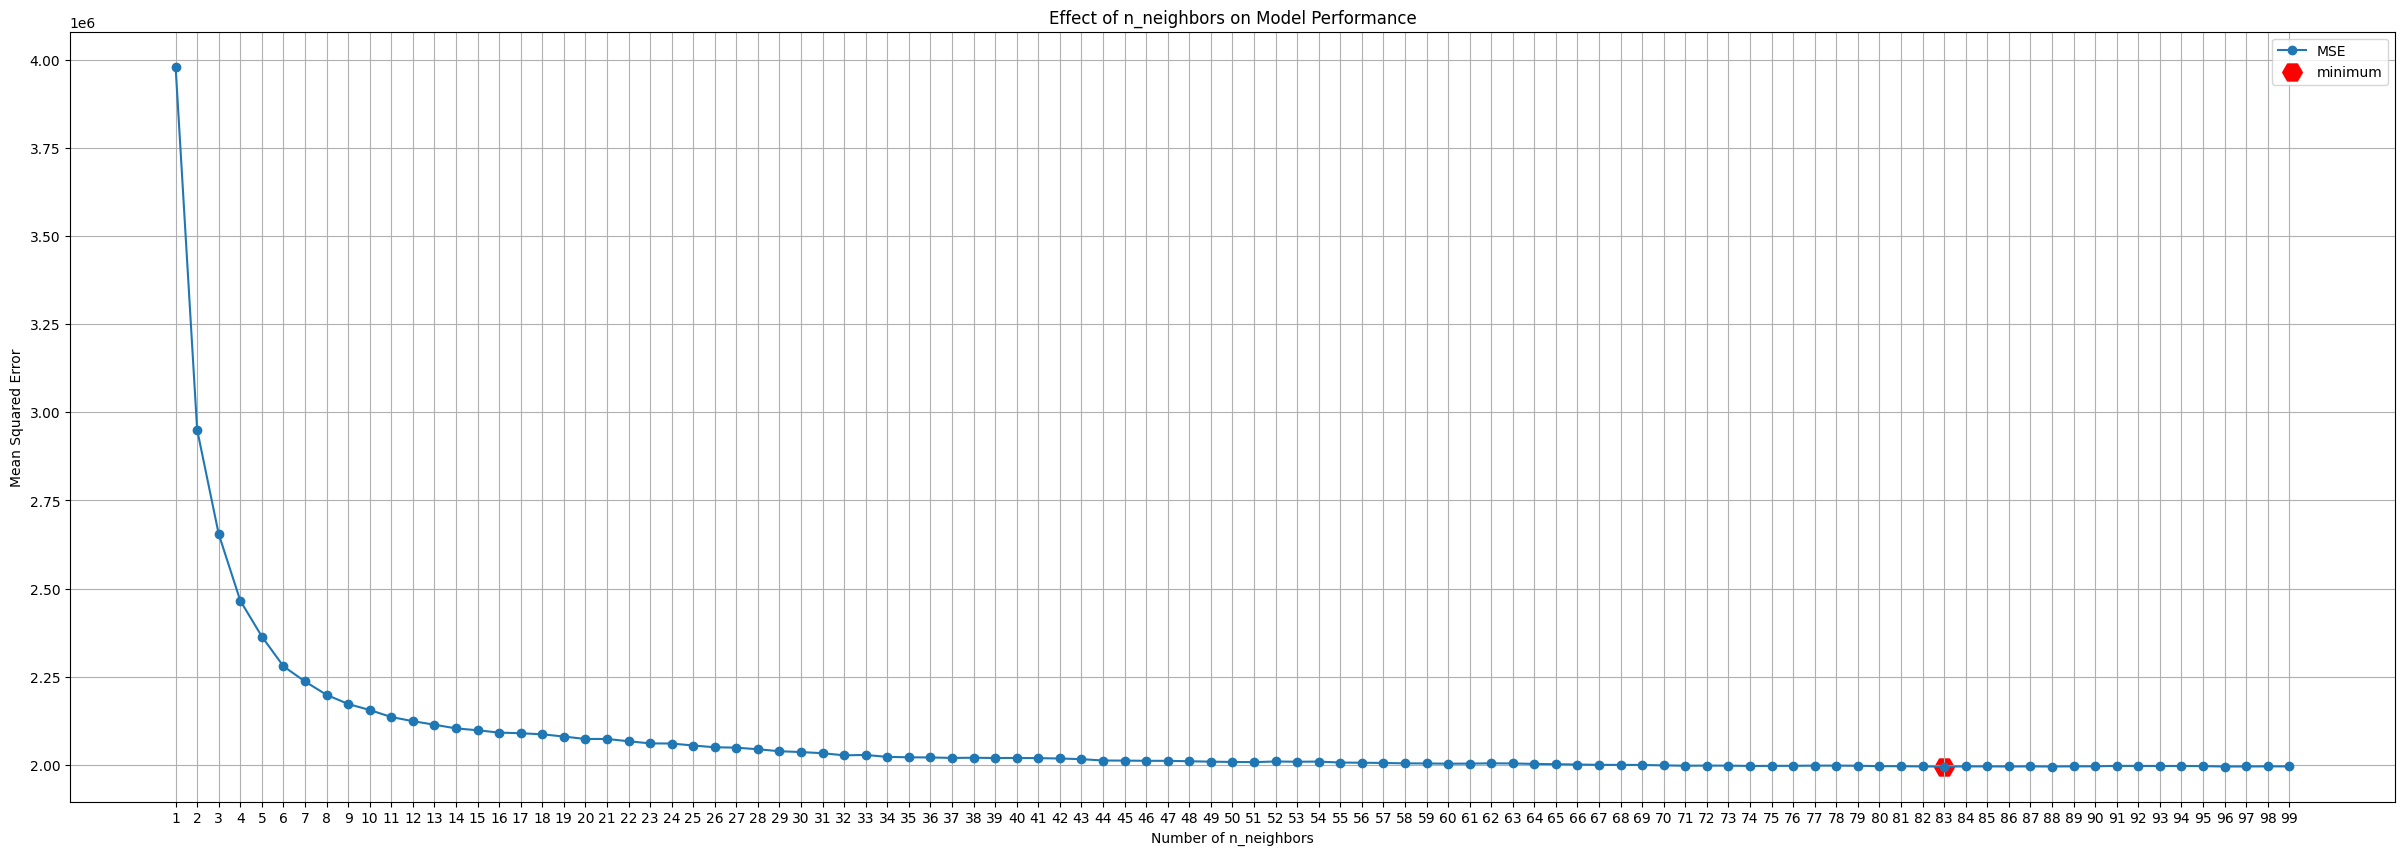

In [37]:
min_x = np.argmin(mse_scores) + 1
min_y = np.min(mse_scores)

plt.figure(figsize=(30, 10))
plt.plot(k_values, mse_scores, marker="o", label="MSE")
plt.scatter(min_x, min_y, c="r", label="minimum", marker="H", s=200)
plt.title("Effect of n_neighbors on Model Performance")
plt.xlabel("Number of n_neighbors")
plt.xticks(k_values)
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid()
plt.show()

In [38]:
from IPython.display import Markdown as md

md(
    f"With this graph, we can see that the larger number of neighbors we have, the better the model perform (indicated by the lower value of MSE). In our example, when testing for number for neighbors ranging from {k_values[0]} to {k_values[-1]}, we can see that the model performs the best when the number of neighbors is {min_x}. Therefore, now we can make a prediction for test.csv with the n_neighbor={min_x}"
)

With this graph, we can see that the larger number of neighbors we have, the better the model perform (indicated by the lower value of MSE). In our example, when testing for number for neighbors ranging from 1 to 99, we can see that the model performs the best when the number of neighbors is 83. Therefore, now we can make a prediction for test.csv with the n_neighbor=83

## Prediction for test.csv

In [39]:
neigh = KNeighborsRegressor(n_neighbors=min_x)
neigh.fit(x_train, y_train)

y_test_pred = neigh.predict(x_test)
test_PredictDF = test_df.copy()
test_PredictDF["Item_Outlet_Sales_Predict"] = y_test_pred
display(test_PredictDF)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales_Predict
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1492.346581
1,FDW14,8.300000,Regular,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,1348.870692
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,3871.330198
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,2083.207983
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,3975.620147
...,...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500000,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1,1864.729323
5677,FDD47,7.600000,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2,2477.915080
5678,NCO17,10.000000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,Medium,Tier 2,Supermarket Type1,1764.361978
5679,FDJ26,15.300000,Regular,0.000000,Canned,214.6218,OUT017,2007,Medium,Tier 2,Supermarket Type1,3036.577431
